# EDA — Fraud Feature Set (CMS Open Payments x LEIE)

Exploratory analysis of `data/processed/fraud_features.csv` before writing
`train_supervised.py` / `train_unsupervised.py`.

- **Source**: `data/processed/fraud_features.csv` — 15,498,687 rows, 20 columns total
  (`Record_ID` + 16 predictive feature columns + 3 label columns), produced by
  `src/features/build_features.py`, which merges `data/processed/fraud_labels.csv`
  against the raw Open Payments CSV by `Record_ID`.
- **Labels** (kept separate here, not combined into one target — that choice belongs to
  the modeling step):
  - `is_excluded` — strict NPI-match label (primary, meant for supervised training).
    Severely imbalanced: **3,809 positives out of 15,498,687 rows (~1:4,070)**.
  - `is_excluded_name_match` — exploratory fuzzy name-match label. Not used for training.
  - `match_confidence` — similarity score (0-1) backing the fuzzy match.
- **This notebook is exploration only**: it does not modify anything under `src/`, and
  does not write any processed data files.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# notebooks/ sits one level below the project root; add the root so `src` is importable.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

FEATURES_PATH = PROCESSED_DATA_DIR / "fraud_features.csv"
FEATURES_PATH

WindowsPath('C:/Users/ADOF_/Curso/Proyectos_nuevos/Proyecto_claude_code_test/data/processed/fraud_features.csv')

## 1. Memory-aware loading

`fraud_features.csv` is **3.39 GB** on disk (15,498,687 rows x 20 columns). This machine
has limited free RAM, so before doing anything we check how much is actually free right
now, and size the loading strategy accordingly.

In [2]:
import ctypes


def free_ram_gb():
    '''Best-effort free-RAM check. Windows-only (ctypes, stdlib); returns None elsewhere.'''
    if sys.platform != "win32":
        return None

    class MEMORYSTATUSEX(ctypes.Structure):
        _fields_ = [
            ("dwLength", ctypes.c_ulong),
            ("dwMemoryLoad", ctypes.c_ulong),
            ("ullTotalPhys", ctypes.c_ulonglong),
            ("ullAvailPhys", ctypes.c_ulonglong),
            ("ullTotalPageFile", ctypes.c_ulonglong),
            ("ullAvailPageFile", ctypes.c_ulonglong),
            ("ullTotalVirtual", ctypes.c_ulonglong),
            ("ullAvailVirtual", ctypes.c_ulonglong),
            ("sullAvailExtendedVirtual", ctypes.c_ulonglong),
        ]

    stat = MEMORYSTATUSEX()
    stat.dwLength = ctypes.sizeof(MEMORYSTATUSEX)
    ctypes.windll.kernel32.GlobalMemoryStatusEx(ctypes.byref(stat))
    return stat.ullAvailPhys / (1024 ** 3)


free_gb = free_ram_gb()
file_gb = FEATURES_PATH.stat().st_size / (1024 ** 3)
if free_gb is not None:
    print(f"Free RAM right now:  {free_gb:.2f} GB")
else:
    print("Free-RAM check only implemented for Windows here — check manually (Task Manager / `free -h`).")
print(f"fraud_features.csv:  {file_gb:.2f} GB on disk "
      f"(typically parses to several times that in pandas, due to object/string overhead)")

Free RAM right now:  0.60 GB
fraud_features.csv:  3.16 GB on disk (typically parses to several times that in pandas, due to object/string overhead)


Free RAM is well under the file's on-disk size, and a naive `pd.read_csv()` of a
20-column CSV with several free-text string columns would balloon past that while
parsing, long before finishing. So instead of one big load, this notebook makes a
**single streaming pass** over the file in chunks:

- **Exact, full-dataset results** (row/null counts, per-category exclusion rates, the
  `is_excluded` x `is_excluded_name_match` cross-tab, and mean/std/min/max of the numeric
  features overall and split by `is_excluded`) are computed by **accumulating** across
  chunks — every row is seen exactly once, nothing is held in memory all at once.
- In the *same* pass, a **stratified sample** is built for the operations that need an
  actual in-memory dataframe (histograms, percentiles, the correlation matrix): **all**
  `is_excluded == 1` rows are kept (only 3,809, trivial), plus a **fixed 2% random
  sample** of `is_excluded == 0` rows (`random_state=42`, reproducible). This
  over-represents the positive class relative to its true 1:4,070 rate — which is
  exactly what we want for *visual* comparison, since a plain uniform sample would leave
  the positive class with almost no points. `sample_df` is **not** representative of the
  true class balance and isn't used for anything that needs to be — the exact stats
  above don't touch it.

This means the CSV is read **once**, and `sample_df` is reused for every section that
needs it below, rather than re-reading per section.

In [3]:
CHUNKSIZE = 150_000
RANDOM_STATE = 42
NEGATIVE_SAMPLE_FRAC = 0.02  # applied only to is_excluded == 0 rows

NUMERIC_COLS = ["payment_amount", "payment_amount_log", "payment_frequency"]
CATEGORICAL_COLS = ["payment_nature", "payment_form", "recipient_specialty", "manufacturer_name"]
TOP_N_CATEGORIES = 15

# dtype overrides to keep each chunk small; the free-text columns (payment_nature,
# payment_form, recipient_specialty, manufacturer_name) are left as default/object -
# a single 300k-row chunk of them is a few tens of MB at most, no need to downcast.
DTYPES = {
    "Record_ID": "int64",
    "payment_amount": "float32",
    "payment_amount_log": "float32",
    "num_payments_included": "float32",
    "manufacturer_id": "float64",
    "payment_month": "float32",
    "payment_day_of_week": "float32",
    "is_ownership_interest": "int8",
    "is_third_party_payment": "int8",
    "is_charity": "int8",
    "is_related_product": "int8",
    "is_disputed": "int8",
    "payment_frequency": "float32",
    "is_excluded": "int8",
    "is_excluded_name_match": "int8",
    "match_confidence": "float32",
}

In [4]:
# --- Single streaming pass over the full file: exact aggregates + stratified sample ---

total_rows = 0
null_counts = None  # pd.Series, per column, accumulated across chunks

# numeric features: overall stats split by is_excluded group, computed via
# sum / sum-of-squares so mean/std can be derived exactly without holding all values
numeric_stats = {
    col: {
        0: {"n": 0, "sum": 0.0, "sumsq": 0.0, "min": np.inf, "max": -np.inf},
        1: {"n": 0, "sum": 0.0, "sumsq": 0.0, "min": np.inf, "max": -np.inf},
    }
    for col in NUMERIC_COLS
}

# categorical features: {column: {category_value: {"count": n, "excluded": n}}}
category_stats = {col: {} for col in CATEGORICAL_COLS}

# is_excluded x is_excluded_name_match contingency table
crosstab_counts = {(0, 0): 0, (0, 1): 0, (1, 0): 0, (1, 1): 0}

sample_chunks = []

reader = pd.read_csv(FEATURES_PATH, chunksize=CHUNKSIZE, dtype=DTYPES, low_memory=False)

for i, chunk in enumerate(reader):
    total_rows += len(chunk)

    chunk_nulls = chunk.isna().sum()
    null_counts = chunk_nulls if null_counts is None else null_counts.add(chunk_nulls, fill_value=0)

    excl = chunk["is_excluded"]
    for col in NUMERIC_COLS:
        vals = chunk[col]
        for group in (0, 1):
            g = vals[excl == group].dropna()
            if len(g) == 0:
                continue
            s = numeric_stats[col][group]
            s["n"] += len(g)
            s["sum"] += float(g.sum())
            s["sumsq"] += float((g.astype("float64") ** 2).sum())
            s["min"] = min(s["min"], float(g.min()))
            s["max"] = max(s["max"], float(g.max()))

    for col in CATEGORICAL_COLS:
        grouped = chunk.groupby(col, dropna=True)["is_excluded"].agg(["count", "sum"])
        stats = category_stats[col]
        for cat, row in grouped.iterrows():
            entry = stats.setdefault(cat, {"count": 0, "excluded": 0})
            entry["count"] += int(row["count"])
            entry["excluded"] += int(row["sum"])

    ct = chunk.groupby(["is_excluded", "is_excluded_name_match"]).size()
    for (a, b), n in ct.items():
        crosstab_counts[(a, b)] += int(n)

    positives = chunk[excl == 1]
    negatives_sample = chunk[excl == 0].sample(frac=NEGATIVE_SAMPLE_FRAC, random_state=RANDOM_STATE)
    sample_chunks.append(positives)
    sample_chunks.append(negatives_sample)

    if (i + 1) % 10 == 0:
        print(f"...processed {total_rows:,} rows")

null_counts = null_counts.astype("int64")
sample_df = pd.concat(sample_chunks, ignore_index=True)
del sample_chunks

print(f"Done. total_rows={total_rows:,}, sample_df.shape={sample_df.shape}")

...processed 1,500,000 rows


...processed 3,000,000 rows


...processed 4,500,000 rows


...processed 6,000,000 rows


...processed 7,500,000 rows


...

...processed 10,500,000 rows


...processed 12,000,000 rows


...processed 13,500,000 rows


...processed 15,000,000 rows


Done. total_rows=15,498,687, sample_df.shape=(313684, 20)


## 2. Shape, dtypes, missingness

In [5]:
print(f"Rows:    {total_rows:,}")
print(f"Columns: {len(null_counts)}")
print()

dtypes_preview = pd.read_csv(FEATURES_PATH, nrows=5, dtype=DTYPES).dtypes
missingness = pd.DataFrame({
    "dtype": dtypes_preview.astype(str),
    "null_count": null_counts.astype("int64"),
    "null_pct": (null_counts / total_rows * 100).round(3),
}).sort_values("null_pct", ascending=False)
missingness

Rows:    15,498,687
Columns: 20



,dtype,null_count,null_pct
payment_frequency,float32,51278,0.331
recipient_specialty,str,37388,0.241
Record_ID,int64,0,0.000
payment_amount,float32,0,0.000
num_payments_included,float32,0,0.000
payment_amount_log,float32,0,0.000
payment_nature,str,0,0.000
payment_form,str,0,0.000
manufacturer_id,float64,0,0.000
payment_month,float32,0,0.000


## 3. Numeric feature distributions

The `count / mean / std / min / max` below come from the full 15,498,687-row streaming
pass — exact, not sampled. Percentiles and the histograms use `sample_df` (the
stratified sample described above).

In [6]:
rows = []
for col in NUMERIC_COLS:
    for group in (0, 1):
        s = numeric_stats[col][group]
        n, total, sumsq = s["n"], s["sum"], s["sumsq"]
        mean = total / n if n else np.nan
        var = sumsq / n - mean ** 2 if n else np.nan
        std = np.sqrt(max(var, 0)) if n else np.nan
        rows.append({
            "feature": col, "is_excluded": group, "n": n,
            "mean": mean, "std": std,
            "min": s["min"] if n else np.nan, "max": s["max"] if n else np.nan,
        })
numeric_summary = pd.DataFrame(rows)
numeric_summary

,feature,is_excluded,n,mean,std,min,max
0,payment_amount,0,15494878,220.749531,39623.870192,0.010000,9.108270e+07
1,payment_amount,1,3809,1012.700614,49968.542259,0.290000,3.082225e+06
2,payment_amount_log,0,15494878,3.304626,1.177324,0.009950,1.832728e+01
3,payment_amount_log,1,3809,3.584787,1.476569,0.254642,1.494116e+01
4,payment_frequency,0,15443600,81.958345,89.988322,1.000000,1.159000e+03
5,payment_frequency,1,3809,99.455763,115.379089,1.000000,3.820000e+02


In [7]:
# Percentiles: from sample_df only (an exact streaming percentile would need a full sort
# or an approximate quantile sketch neither of which is worth the complexity here).
sample_df.groupby("is_excluded")[NUMERIC_COLS].describe(percentiles=[.25, .5, .75, .95, .99]).T

is_excluded                          0             1
payment_amount     count  3.098750e+05  3.809000e+03
                   mean   2.184967e+02  1.012701e+03
                   std    1.104122e+04  4.997510e+04
                   min    1.000000e-02  2.900000e-01
                   25%    1.534000e+01  1.588000e+01
                   50%    2.040000e+01  2.138000e+01
                   75%    2.918000e+01  3.362000e+01
                   95%    2.429130e+02  8.272000e+02
                   99%    3.150000e+03  2.046000e+03
                   max    4.137911e+06  3.082225e+06
payment_amount_log count  3.098750e+05  3.809000e+03
                   mean   3.306016e+00  3.584787e+00
                   std    1.176996e+00  1.476763e+00
                   min    9.950330e-03  2.546422e-01
                   25%    2.793616e+00  2.826129e+00
                   50%    3.063391e+00  3.108168e+00
                   75%    3.407179e+00  3.544431e+00
                   95%    5.496812e+00  6.719254e+00
                   99%    8.055475e+00  7.624108e+00
                   max    1.523570e+01  1.494116e+01
payment_frequency  count  3.088930e+05  3.809000e+03
                   mean   8.207286e+01  9.945576e+01
                   std    9.017416e+01  1.153942e+02
                   min    1.000000e+00  1.000000e+00
                   25%    2.200000e+01  1.800000e+01
                   50%    5.600000e+01  5.600000e+01
                   75%    1.120000e+02  1.950000e+02
                   95%    2.410000e+02  3.820000e+02
                   99%    4.250000e+02  3.820000e+02
                   max    1.159000e+03  3.820000e+02

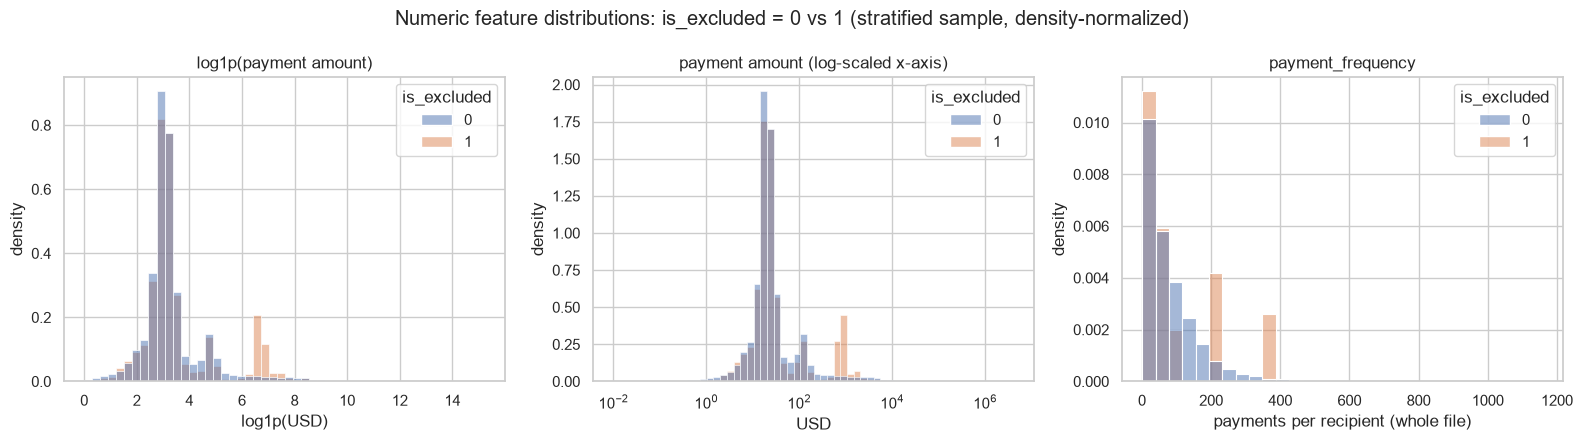

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(data=sample_df, x="payment_amount_log", hue="is_excluded",
             stat="density", common_norm=False, bins=50, ax=axes[0])
axes[0].set_title("log1p(payment amount)")
axes[0].set_xlabel("log1p(USD)")
axes[0].set_ylabel("density")

sns.histplot(data=sample_df[sample_df["payment_amount"] > 0], x="payment_amount", hue="is_excluded",
             stat="density", common_norm=False, bins=60, log_scale=True, ax=axes[1])
axes[1].set_title("payment amount (log-scaled x-axis)")
axes[1].set_xlabel("USD")
axes[1].set_ylabel("density")

sns.histplot(data=sample_df, x="payment_frequency", hue="is_excluded",
             stat="density", common_norm=False, bins=30, ax=axes[2])
axes[2].set_title("payment_frequency")
axes[2].set_xlabel("payments per recipient (whole file)")
axes[2].set_ylabel("density")

fig.suptitle("Numeric feature distributions: is_excluded = 0 vs 1 (stratified sample, density-normalized)")
fig.tight_layout()
plt.show()

## 4. Categorical features: frequency and exclusion rate

Top categories by row count for each column (exact counts, full dataset), with the
`is_excluded` positive rate within each category — this is where a disproportionately
risky specialty / payment type / manufacturer would show up.

In [9]:
overall_rate = (crosstab_counts[(1, 0)] + crosstab_counts[(1, 1)]) / total_rows

category_tables = {}
for col in CATEGORICAL_COLS:
    df_cat = pd.DataFrame.from_dict(category_stats[col], orient="index")
    df_cat["exclusion_rate_pct"] = df_cat["excluded"] / df_cat["count"] * 100
    df_cat = df_cat.sort_values("count", ascending=False).head(TOP_N_CATEGORIES)
    category_tables[col] = df_cat
    print(f"\n=== {col} (top {TOP_N_CATEGORIES} by row count; overall exclusion rate = {overall_rate * 100:.4f}%) ===")
    display(df_cat)


=== payment_nature (top 15 by row count; overall exclusion rate = 0.0246%) ===


,count,excluded,exclusion_rate_pct
Food and Beverage,14178579,3188,0.022485
Travel and Lodging,608178,49,0.008057
"Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program",241927,28,0.011574
Consulting Fee,189386,447,0.236026
Education,156118,31,0.019857
Gift,28441,10,0.035161
Long term medical supply or device loan,18781,18,0.095842
Honoraria,16603,2,0.012046
Royalty or License,15479,0,0.000000
Compensation for serving as faculty or as a speaker for a medical education program,14125,0,0.000000



=== payment_form (top 15 by row count; overall exclusion rate = 0.0246%) ===


,count,excluded,exclusion_rate_pct
In-kind items and services,13428176,3018,0.022475
Cash or cash equivalent,2069911,791,0.038214
"Dividend, profit or other return on investment",255,0,0.000000
"Stock, stock option, or any other ownership interest",214,0,0.000000
Stock option,104,0,0.000000
Stock,27,0,0.000000



=== recipient_specialty (top 15 by row count; overall exclusion rate = 0.0246%) ===


,count,excluded,exclusion_rate_pct
Physician Assistants & Advanced Practice Nursing Providers|Nurse Practitioner|Family,1499092,147,0.009806
Physician Assistants & Advanced Practice Nursing Providers|Physician Assistant,1394057,75,0.005380
Allopathic & Osteopathic Physicians|Internal Medicine,1190407,561,0.047127
Physician Assistants & Advanced Practice Nursing Providers|Nurse Practitioner,1126224,80,0.007103
Allopathic & Osteopathic Physicians|Family Medicine,1120019,807,0.072052
Allopathic & Osteopathic Physicians|Dermatology,527325,0,0.000000
Allopathic & Osteopathic Physicians|Psychiatry & Neurology|Neurology,462531,21,0.004540
Allopathic & Osteopathic Physicians|Internal Medicine|Gastroenterology,457577,31,0.006775
Allopathic & Osteopathic Physicians|Internal Medicine|Cardiovascular Disease,455620,58,0.012730
Physician Assistants & Advanced Practice Nursing Providers|Nurse Practitioner|Psychiatric/Mental Health,431955,71,0.016437



=== manufacturer_name (top 15 by row count; overall exclusion rate = 0.0246%) ===


,count,excluded,exclusion_rate_pct
ABBVIE INC.,1721201,429,0.024924
AstraZeneca Pharmaceuticals LP,614064,175,0.028499
PFIZER INC.,570284,138,0.024198
"Lilly USA, LLC",544473,109,0.020019
Novo Nordisk Inc,495369,174,0.035125
Amgen Inc.,474864,88,0.018532
Novartis Pharmaceuticals Corporation,411213,60,0.014591
"Medtronic, Inc.",342681,32,0.009338
"GlaxoSmithKline, LLC.",341439,79,0.023137
"Janssen Biotech, Inc.",298174,36,0.012073


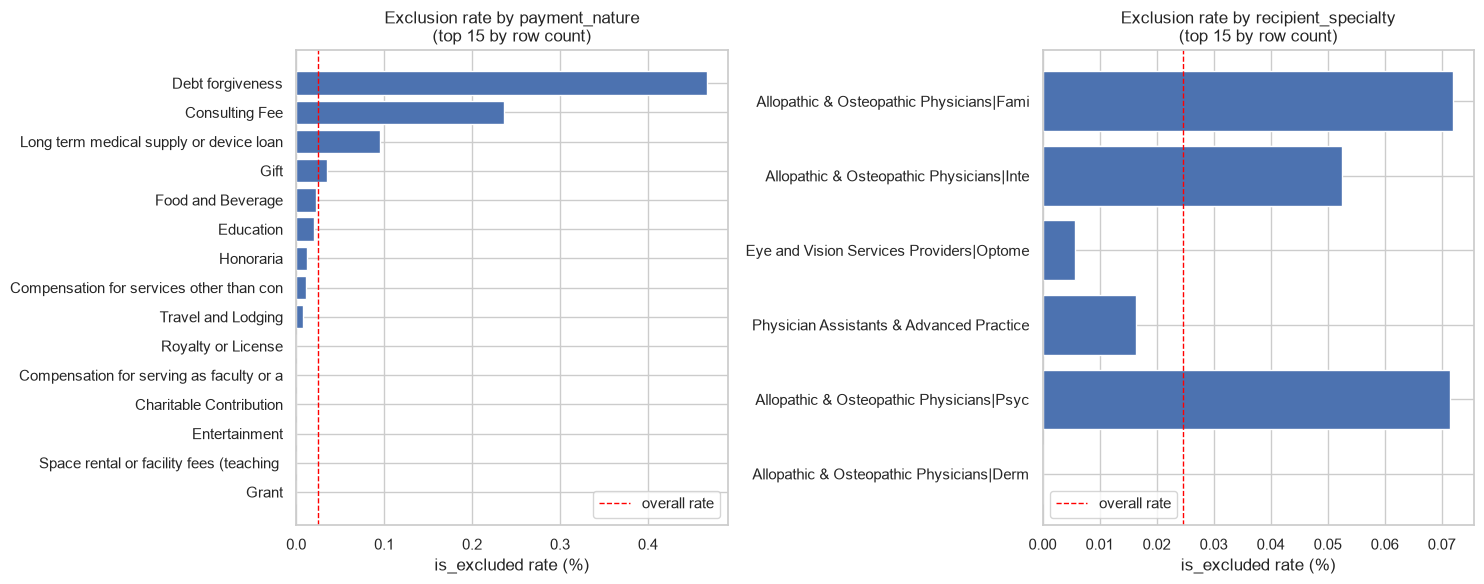

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, col in zip(axes, ["payment_nature", "recipient_specialty"]):
    df_cat = category_tables[col].sort_values("exclusion_rate_pct", ascending=True)
    labels = df_cat.index.astype(str).str.slice(0, 40)
    ax.barh(labels, df_cat["exclusion_rate_pct"])
    ax.axvline(overall_rate * 100, color="red", linestyle="--", linewidth=1, label="overall rate")
    ax.set_xlabel("is_excluded rate (%)")
    ax.set_title(f"Exclusion rate by {col}\n(top {TOP_N_CATEGORIES} by row count)")
    ax.legend()
fig.tight_layout()
plt.show()

## 5. `is_excluded` vs `is_excluded_name_match`: overlap

In [11]:
ct = pd.DataFrame(
    [[crosstab_counts[(0, 0)], crosstab_counts[(0, 1)]],
     [crosstab_counts[(1, 0)], crosstab_counts[(1, 1)]]],
    index=pd.Index([0, 1], name="is_excluded"),
    columns=pd.Index([0, 1], name="is_excluded_name_match"),
)
display(ct)

n_excl = crosstab_counts[(1, 0)] + crosstab_counts[(1, 1)]
n_name = crosstab_counts[(0, 1)] + crosstab_counts[(1, 1)]
overlap = crosstab_counts[(1, 1)]
print(f"is_excluded=1 rows:              {n_excl:,}")
print(f"is_excluded_name_match=1 rows:   {n_name:,}")
print(f"rows where BOTH are 1:           {overlap:,}")
print(f"  -> {overlap / n_excl * 100:.2f}% of strict NPI matches also got a fuzzy name match")
print(f"  -> {overlap / n_name * 100:.2f}% of fuzzy name matches also got a strict NPI match")

is_excluded_name_match,0,1
is_excluded,,
0,15210857,284021
1,3717,92


is_excluded=1 rows:              3,809
is_excluded_name_match=1 rows:   284,113
rows where BOTH are 1:           92
  -> 2.42% of strict NPI matches also got a fuzzy name match
  -> 0.03% of fuzzy name matches also got a strict NPI match


## 6. Correlation among numeric features

Computed on `sample_df` (the stratified sample) — a correlation matrix is stable under
sampling at this size, unlike the rare-event stats in sections 3-5, which use the exact
full-dataset accumulation instead.

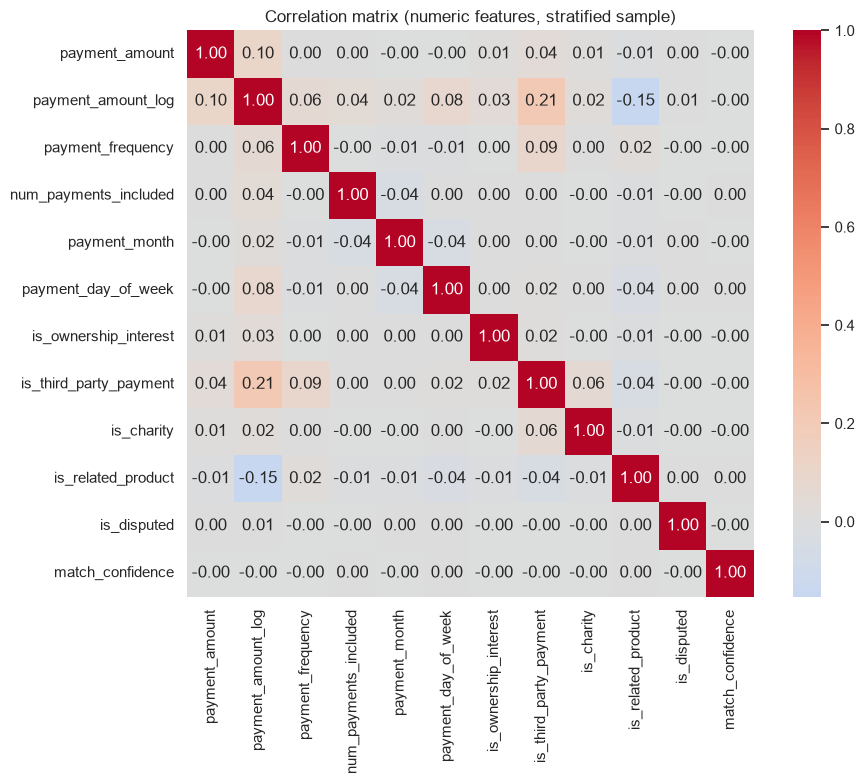

,feature_1,feature_2,corr


In [12]:
corr_cols = NUMERIC_COLS + [
    "num_payments_included", "payment_month", "payment_day_of_week",
    "is_ownership_interest", "is_third_party_payment", "is_charity",
    "is_related_product", "is_disputed", "match_confidence",
]
corr = sample_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation matrix (numeric features, stratified sample)")
fig.tight_layout()
plt.show()

strong_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
)
strong_pairs.columns = ["feature_1", "feature_2", "corr"]
strong_pairs = strong_pairs[strong_pairs["corr"].abs() >= 0.5].sort_values("corr", key=abs, ascending=False)
strong_pairs

## 7. Red flags for modeling

Grounded in the actual output above (full 15,498,687-row pass unless noted as sample-based).

1. **`is_excluded` class imbalance is as severe as advertised**: 3,809 positives out of
   15,498,687 rows (~1:4,070). `build_features.py` deliberately applies no resampling —
   `train_supervised.py` needs an explicit strategy (`class_weight`, undersampling,
   focal loss, PR-AUC-based thresholding, etc.), or a model will just predict the
   majority class and look "accurate" while being useless.

2. **`is_excluded` and `is_excluded_name_match` overlap almost not at all**: only 92 rows
   have both labels = 1 — just 2.42% of the 3,809 strict NPI matches, and 0.03% of the
   284,113 fuzzy name matches. This is **expected by construction**, not a bug: in
   `clean_data.py`, the fuzzy match only searches LEIE rows *without* a valid NPI, while
   the strict match only uses LEIE rows *with* one — the two labels are built from
   largely disjoint LEIE subsets. Don't use `is_excluded_name_match` as a sanity check
   against `is_excluded` (they're not supposed to agree), and don't feed both into a
   supervised model as if they were independent evidence of the same thing.

3. **Near-constant binary indicator features** — four of the five `is_*` payment
   indicators are almost always one single value:
   - `is_disputed`: 327 / 15,498,687 positive (**0.0021%**)
   - `is_charity`: 756 / 15,498,687 positive (**0.0049%**)
   - `is_ownership_interest`: 4,014 / 15,498,687 positive (**0.0259%**)
   - `is_related_product`: 14,537,723 / 15,498,687 positive (**93.80%**) — the mirror
     case, minority class is "No" at only ~6.2%.
   - (`is_third_party_payment` is less extreme at 0.92% positive.)

   These carry very little variance for a generic classifier to split on. They may still
   matter if the rare/minority value correlates strongly with fraud (not evaluated here —
   worth a targeted look before dropping any of them), but don't expect much from them
   as-is, and don't be surprised if a tree-based model barely uses them.

4. **`recipient_specialty` and `payment_frequency` nulls are structural, not random**:
   0.241% and 0.331% null respectively, tied to `Covered_Recipient_Type == "Teaching
   Hospital"` rows that have no individual NPI (confirmed against the raw file earlier
   in this project). Small enough to not be a blocker, but they should be **imputed or
   flagged**, not silently dropped — dropping rows on null would systematically remove
   every teaching-hospital payment.

5. **`payment_amount` is extremely heavy-tailed** — for `is_excluded == 0`: mean $220.75
   but std $39,624 (max ~$91.1M); for `is_excluded == 1`: mean $1,012.70 but std $49,969
   (max ~$3.08M). The *mean* payment is ~4.6x higher for excluded providers, but the
   *median* is nearly identical ($20.40 vs $21.38 in the sample) — the separation lives
   almost entirely in the upper tail (95th percentile: $242.9 vs $827.2), not in a
   shifted center. A model relying on raw mean/central-tendency comparisons would miss
   this; **use `payment_amount_log` as the primary numeric feature**, not raw
   `payment_amount`.

6. **Pearson correlation is a poor multicollinearity check for `payment_amount`
   specifically**: despite `payment_amount_log` being a direct transform of
   `payment_amount`, no pair in the correlation matrix reached the ±0.5 threshold used
   for `strong_pairs` (it came back empty) — the extreme outliers in raw
   `payment_amount` dominate its variance enough to suppress the linear correlation with
   its own log. Don't read "no strong pairs" as "no redundant features" for this
   specific pair; it's a known quirk of Pearson correlation on heavy-tailed data, not
   evidence the two columns are independent.

7. **`payment_nature` categories show real spread in exclusion rate**: `Debt
   forgiveness` (0.467%, ~19x the 0.0246% overall rate, n=7,704) and `Consulting Fee`
   (0.236%, ~9.6x, n=189,386) stand out well above baseline, while `Royalty or License`,
   `Grant`, `Entertainment`, `Charitable Contribution`, and `Space rental` show exactly
   **0** excluded rows despite thousands of samples each. Worth surfacing as a candidate
   high-signal categorical feature — but see the next point before trusting the 0%
   categories.

8. **Some categories are too small to trust their exclusion rate** — within
   `payment_form`, the four stock/dividend-related categories (`Stock`, `Stock option`,
   `Dividend...`, `Stock, stock option...`) total only **600 rows combined** out of
   15.5M, all showing 0% exclusion. That's very plausibly just "too few samples to have
   hit a positive yet," not a genuinely zero-risk payment form. The same caution applies
   to the 0%-exclusion `payment_nature` categories above (`Grant` n=7,510,
   `Entertainment` n=6,562, `Charitable Contribution` n=807 — the last one in particular
   is thin). Bucket rare categories into an "other" group rather than trusting their
   individual rates.

9. **`recipient_specialty` has high cardinality with a wide exclusion-rate spread even
   among just the top 15** (0.0045% to 0.072% — a ~16x range, e.g. Family Medicine and
   Psychiatry & Neurology sit well above baseline while Dermatology shows 0% over
   527,325 rows). One-hot encoding the full long tail is likely to be noisy; target/
   frequency encoding or grouping by the broader `|`-delimited category prefix is
   probably more robust.

10. **`manufacturer_id` is redundant with `manufacturer_name`** — same identifying
    information in numeric vs. string form. Keep one, not both, to avoid a pointless
    duplicate/collinear feature.

11. **`Record_ID` is a row identifier, not a feature** — it must be excluded from model
    input entirely (obvious, but an easy accidental-inclusion mistake given it's the
    first column in the file).


## 8. Does the rare value of each near-constant flag concentrate in `is_excluded=1`?

Section 7 flagged `is_disputed`, `is_charity`, `is_ownership_interest`, and
`is_related_product` as near-constant (and `is_third_party_payment` as less extreme but
still skewed) — almost no variance overall. But low overall variance doesn't rule out
the rare value being disproportionately common specifically among the 3,809
`is_excluded == 1` rows, which would still make a flag useful despite looking
"degenerate" in aggregate. This section checks that directly, using **exact counts over
the full 15,498,687-row file** — not the stratified sample used elsewhere in this
notebook. With `is_excluded=1` already down to 3,809 rows, and each flag's rare value
rarer still, the sample doesn't have enough joint rare-flag-and-excluded rows to give a
reliable rate.

Nothing computed in the streaming pass above covers these flags per `is_excluded` group
(that pass only accumulated numeric stats for `payment_amount`, `payment_amount_log`,
and `payment_frequency`), so this re-reads the CSV — but only the 6 columns needed (the
5 flags + `is_excluded`), not the full 20-column file.


In [1]:
## Self-contained: re-imports/redefines what it needs so this section can run on its
# own (fresh kernel), without depending on the ~15-20 min full pass in the cells above
# having just run in this same session.
import sys
from pathlib import Path

import numpy as np
import pandas as pd

if "PROJECT_ROOT" not in dir():
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

FEATURES_PATH = PROCESSED_DATA_DIR / "fraud_features.csv"
SECTION8_CHUNKSIZE = 300_000

FLAG_COLS = [
    "is_disputed", "is_charity", "is_ownership_interest",
    "is_related_product", "is_third_party_payment",
]
# The "rare" value for each flag - 1 (the positive/"Yes" encoding) for four of them,
# but 0 for is_related_product, whose majority value is 1 (93.80% per section 7).
RARE_VALUE = {
    "is_disputed": 1,
    "is_charity": 1,
    "is_ownership_interest": 1,
    "is_related_product": 0,
    "is_third_party_payment": 1,
}

flag_counts = {col: {0: {"n": 0, "rare": 0}, 1: {"n": 0, "rare": 0}} for col in FLAG_COLS}

reader = pd.read_csv(
    FEATURES_PATH,
    usecols=FLAG_COLS + ["is_excluded"],
    dtype={c: "int8" for c in FLAG_COLS + ["is_excluded"]},
    chunksize=SECTION8_CHUNKSIZE,
)
rows_seen = 0
for chunk in reader:
    rows_seen += len(chunk)
    excl = chunk["is_excluded"].to_numpy()
    for col in FLAG_COLS:
        rare_val = RARE_VALUE[col]
        vals = chunk[col].to_numpy()
        for group in (0, 1):
            mask = excl == group
            n = int(mask.sum())
            rare = int((vals[mask] == rare_val).sum())
            flag_counts[col][group]["n"] += n
            flag_counts[col][group]["rare"] += rare

print(f"rows processed: {rows_seen:,}")


rows processed: 15,498,687


In [2]:
rows = []
for col in FLAG_COLS:
    rare_val = RARE_VALUE[col]
    n0, r0 = flag_counts[col][0]["n"], flag_counts[col][0]["rare"]
    n1, r1 = flag_counts[col][1]["n"], flag_counts[col][1]["rare"]
    rate0 = r0 / n0 if n0 else np.nan
    rate1 = r1 / n1 if n1 else np.nan
    lift = (rate1 / rate0) if rate0 else np.inf
    rows.append({
        "flag": col,
        "rare_value": rare_val,
        "rare_rate_pct_in_excluded": rate1 * 100,
        "rare_rate_pct_in_non_excluded": rate0 * 100,
        "lift_ratio": lift,
        "n_rare_within_excluded": r1,
        "n_excluded_total": n1,
    })
lift_summary = pd.DataFrame(rows).sort_values("lift_ratio", ascending=False)
lift_summary


,flag,rare_value,rare_rate_pct_in_excluded,rare_rate_pct_in_non_excluded,lift_ratio,n_rare_within_excluded,n_excluded_total
3,is_related_product,0,17.222368,6.197583,2.778884,656,3809
4,is_third_party_payment,1,0.420058,0.916806,0.458175,16,3809
0,is_disputed,1,0.000000,0.002110,0.000000,0,3809
2,is_ownership_interest,1,0.000000,0.025905,0.000000,0,3809
1,is_charity,1,0.000000,0.004879,0.000000,0,3809


**Conclusion**, from the exact full-dataset lift table above:

| flag | rare value | rate in excluded | rate in non-excluded | lift |
|---|---|---|---|---|
| `is_related_product` | 0 ("No") | **17.22%** | 6.20% | **2.78x** |
| `is_third_party_payment` | 1 | 0.42% | 0.92% | 0.46x |
| `is_disputed` | 1 | 0.00% | 0.0021% | 0.00x |
| `is_ownership_interest` | 1 | 0.00% | 0.0259% | 0.00x |
| `is_charity` | 1 | 0.00% | 0.0049% | 0.00x |

- **Keep `is_related_product` despite its low overall variance.** Its rare value ("No",
  the payment isn't tied to a specific drug/device/biological) shows up in 17.22% of
  `is_excluded=1` rows vs. 6.20% of `is_excluded=0` rows — a genuine **2.78x lift**, not
  noise: 656 of the 3,809 excluded rows carry it. Low aggregate variance was hiding a
  real, non-trivial signal here.
- **`is_third_party_payment` goes the *other* direction** — its "Yes" value is actually
  **less** common among excluded rows (0.42%) than non-excluded (0.92%), lift 0.46x, not
  the hypothesized "rare value concentrates in fraud" pattern. It may still carry some
  signal (an association exists, just an inverse one, off only 16 excluded rows), but it
  doesn't support the "keep despite low variance" case the way `is_related_product`
  does — treat it as a weak, uncertain feature rather than a confirmed one.
- **`is_disputed`, `is_ownership_interest`, and `is_charity` are confirmed safe to
  deprioritize.** Their rare value occurs in **zero** of the 3,809 `is_excluded=1` rows —
  not just "near 1.0 lift," but a literal 0/3,809, with no counter-evidence to the
  "near-constant → low value" read from section 7. Unless a future iteration finds a
  reason to revisit them (e.g. combined with other features in an interaction term),
  they're reasonable candidates to drop from `train_supervised.py`'s feature set.
